# 📊 Programming in Data Analytics

Elise Margaret E. Junsay

24-1-0051

## Data Import and Cleaning

In [10]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df1 = pd.read_excel('data.xlsx', sheet_name ='Program Info')
df2 = pd.read_excel('data.xlsx', sheet_name ='Profile')
df3 = pd.read_excel('data.xlsx', sheet_name ='SIS and OASIS Data-Grades')

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

df3["Final Grade"] = pd.to_numeric(df3["Final Grade"], errors="coerce")

# Check if 'Unnamed: 17' column exists before dropping it
if "Unnamed: 17" in df2.columns:
    df2 = df2.drop(columns=["Unnamed: 17"])

## Basic EDA

The exploratory data analysis was used to give a general picture of the data set, to clean up the anomalies in the data and summarize the most important variables. It emphasized the overall distributions, found outliers, and made sure that all the data was prepared to be analyzed further in terms of demographics and academic interests.


## Head

Loading the first pile of the rows, preview your data (not specifying a number means it will only show the first 5)


In [12]:
df1.head()

,Code,No. of terms/sems
0,Program 01,11
1,Program 02,12
2,Program 03,8
3,Program 04,7
4,Program 05,5


### Insights

This illustrates the variability in program length, which ranges from shorter programs of 5 terms to longer ones with 12 terms. This diversity is important for understanding program structures and potential impact on student progression.

In [13]:
df2.head()

,Program,Program Status,Student,Nationality,Age upon date of entry,Gender by Birth,Civil Status,Highest Degree Obtained,Position,Industry (old),Source of Funding,Date of Application for \nLeave of Absence/Withdrawal,Date of Last Attended Class,Last Term Attended,Week number of the term in which \nthe student last attended classes,Reason (code),Student Status,NaN
0,Program 01,On-going,S1826,India,18.0,Female,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Program 01,On-going,S1827,Philippines,18.0,Female,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Program 01,On-going,S1828,Philippines,17.0,Male,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Program 01,On-going,S1829,Philippines,18.0,Male,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Program 01,On-going,S1830,Philippines,18.0,Male,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Insights

Many fields such as "Highest Degree Obtained," "Position," "Industry (old)," "Source of Funding," and attendance-related dates are missing (NaN), indicating data gaps.

The data suggests active enrollment but limited additional demographic or academic detail available for this group.

In [14]:
df3.head(10)

,Academic Year,Student,Section & Term,Courses,Final Grade
0,AY 2018-2019,S0481,2020-T1-9,Course 180,3.50
1,AY 2018-2019,S0481,2020-T1-9,Course 247,3.50
2,AY 2018-2019,S0481,2020-T1-9,Course 255,3.00
3,AY 2018-2019,S0481,2020-T1-9,Course 370,3.75
4,AY 2018-2019,S0481,2020-T1-9,Course 449,3.50
5,AY 2018-2019,S0481,2020-T1-9,Course 460,3.75
6,AY 2018-2019,S0481,2020-T1-9,Course 532,4.75
7,AY 2018-2019,S0481,2020-T1-9,Course 653,4.00
8,AY 2018-2019,S0481,2020-T1-9,Course 654,3.75
9,AY 2018-2019,S0481,2020-T1-9,Course 662,3.75


### Insights

These grades indicate generally good performance across various courses during this term. The granularity of data allows for tracking student performance across courses and terms for comprehensive academic analysis.

## Tail

Shows the last rows of your dataset (not specifying a number means it will only show the first 5)

In [15]:
df1.tail()

,Code,No. of terms/sems
67,Program 68,6
68,Program 69,12
69,Program 70,12
70,Program 71,12
71,Program 72,12


### Insights

This confirms that towards the end of the program list, several programs have the maximum length of 12 terms, with one shorter program at 6 terms. The data reflects program length diversity through the full range of programs.

In [16]:
df2.tail(10)

,Program,Program Status,Student,Nationality,Age upon date of entry,Gender by Birth,Civil Status,Highest Degree Obtained,Position,Industry (old),Source of Funding,Date of Application for \nLeave of Absence/Withdrawal,Date of Last Attended Class,Last Term Attended,Week number of the term in which \nthe student last attended classes,Reason (code),Student Status,NaN
3355,Program 71,On-going,S1798,Philippines,58.0,Male,Married,Master of Liberal Arts in Extension Studies - ...,"Founder, Chairperson, Chief Technology Officer",Education Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3356,Program 69,Concluded,S0827,Philippines,31.0,Male,Single,Master of Science,NaN,NaN,NaN,NaN,2022-03-23,5,11.0,Reason M,Leave of absence,NaN
3357,Program 69,Concluded,S0829,Philippines,28.0,Male,Single,Master of Science in Data Science,NaN,NaN,NaN,NaN,2023-06-23,11,0.0,Reason M,Leave of absence,NaN
3358,Program 71,On-going,S1801,Philippines,32.0,Male,Single,Master in Applied Business Economics,Senior Lead Analyst,Manufacturing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3359,Program 69,Concluded,S0831,Philippines,29.0,Female,Single,Bachelor of Science in Applied Physics,NaN,NaN,NaN,NaN,2022-03-07,5,8.0,Reason I,Withdrawn,NaN
3360,Program 70,Concluded,S1029,Philippines,28.0,Male,Married,Master of Science in Data Science,Data Scientist,Education,Self-Financed and scholarship,NaN,2022-11-26,5,9.0,Reason M,Withdrawn,NaN
3361,Program 71,On-going,S1804,Philippines,45.0,Male,Single,Doctor of Letters,Senior Structural Health Engineer,"Manufacturing, R&D, Sales & Marketing",Self-Financed and scholarship,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3362,Program 72,On-going,S1102,Philippines,35.0,Female,Single,Master In International Health,Project Officer IV (Data Scientist,Academe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3363,Program 72,On-going,S2674,Philippines,25.0,Male,Married,Master of Science in Data Science,Data Scientist,Consultancy,Self Financed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3364,Program 72,On-going,S2694,Philippines,31.0,Male,Single,Master of Engineering Major in Communications ...,Chairperson,Academe,Self Financed,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Insights

Dates related to leave of absence or last attended classes are largely missing except a few records indicating leaves or withdrawals.

This subset demonstrates detailed academic and professional diversity, highlighting both continuing and completed students with differing backgrounds and statuses, which is vital for retention and success analyses.

In [17]:
df3.tail()

,Academic Year,Student,Section & Term,Courses,Final Grade
83013,SY 2021-2022,S0897,Term 3,Course 725,NaN
83014,SY 2021-2022,S0897,Term 3,Course 324,NaN
83015,SY 2021-2022,S0897,Term 3,Course 473,NaN
83016,SY 2021-2022,S0897,Term 4,Course 311,NaN
83017,SY 2021-2022,S0897,Term 4,Course 86,NaN


### Insights

The data snippet shows several course records for student S0817 in academic year SY 2021-2022 across Term 3 and Term 4, where all the "Final Grade" values are NaN (missing).

This indicates that for these courses and term sections, the student's grades were not recorded or are unavailable, possibly due to ongoing enrollment, incomplete grading, or data entry gaps.

## Info

Shows how many non-null per column

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Code               72 non-null     object
 1   No. of terms/sems  72 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ KB


### Insights

This compact dataset provides program duration information essential for analyzing program length effects on student progress and performance.

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3365 entries, 0 to 3364
Data columns (total 18 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Program                                                              3365 non-null   object 
 1   Program Status                                                       3365 non-null   object 
 2   Student                                                              3364 non-null   object 
 3   Nationality                                                          3356 non-null   object 
 4   Age upon date of entry                                               3362 non-null   float64
 5   Gender by Birth                                                      3363 non-null   object 
 6   Civil Status                                                         3365 non-null   object 
 7   Highes

### Insights

While most demographic and program status data are nearly complete, fields related to leave of absence, withdrawal reasons, and last attended classes have very sparse data.

In [20]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83018 entries, 0 to 83017
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Academic Year   83018 non-null  object 
 1   Student         83018 non-null  object 
 2   Section & Term  83018 non-null  object 
 3   Courses         83018 non-null  object 
 4   Final Grade     61971 non-null  float64
dtypes: float64(1), object(4)
memory usage: 3.2+ MB


### Insights

The presence of over 21,000 missing final grades (almost 25%) could indicate incomplete grade recording or courses without grades assigned yet, which is important for analysis and may require handling missing values or imputation.



## Value Counts

Shows the categorical values

In [45]:
df1.value_counts()

,,count
Code,No. of terms/sems,
Program 01,11,1
Program 02,12,1
Program 03,8,1
Program 04,7,1
Program 05,5,1
...,...,...
Program 68,6,1
Program 69,12,1
Program 70,12,1


### Insights

Highlights the diversity in program length across the dataset, which can influence students’ academic journey and completion timelines. The count of 1 confirms no duplicates in this program-term duration data.

In [44]:
print(df2["Highest Degree Obtained"].value_counts())

Highest Degree Obtained
Bachelor of Science in Accountancy                     163
Bachelor of Science in Nursing                          53
Juris Doctor                                            50
Bachelor of Science in Civil Engineering                46
Bachelor of Science in Mechanical Engineering           41
                                                      ... 
Bachelor of Science Major in Naval Studies               1
Master in Management Major in Public Administration      1
Bachelor of Science in Marketing                         1
B.S. Computer Engineering                                1
AB Philosophy - Pre-Divinity Track                       1
Name: count, Length: 1392, dtype: int64


### Insights

This insight helps in understanding the heterogeneity of student academic backgrounds, which can guide tailored academic support, program design, and advising services to better accommodate differing qualifications and career goals.

In [24]:
df3.value_counts()

Academic Year   Student  Section & Term       Courses     Final Grade
SY 2016 - 2017  S0007    Term 1               Course 502  3.00           6
                                              Course 519  4.50           6
                                              Course 577  3.25           6
                                              Course 639  3.50           6
                                              Course 692  3.75           6
                                                                        ..
AY 2022-2023    S2228    2023-1-Y2022-AQ3-T1  Course 193  4.00           1
                                              Course 416  4.00           1
                                              Course 664  4.50           1
                                              Course 676  4.25           1
                S2227    2023-1-Y2022-AQ3-T1  Course 193  4.25           1
Name: count, Length: 58392, dtype: int64

### Insights

This data enables analysis of student progression across terms, performance consistency, and trends over multiple years for in-depth academic evaluation and prediction modeling.

## Shape

Shows how many rows and columns (50gb is considered a big data set)

In [25]:
df1.shape

(72, 2)

### Insights

72 rows, 2 columns (program code and number of terms/semesters).

In [26]:
df2.shape

(3365, 18)

### Insights

3,365 rows, 18 columns (student demographics, program status, academic info).

In [27]:
df3.shape

(83018, 5)

### Insights

83,018 rows, 5 columns (academic year, student, term, course, final grade).

## Describe

Statistical summary

.T - transpose (rows will be columns, columns will be rows)

count - how many values in a column (ignores the empty columns)

mean - average of all values

std - how spread out the values are

min - smallest value

max - largest value

In [28]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
No. of terms/sems,72.0,6.069444,2.190417,3.0,4.0,6.0,7.0,12.0


### Insights

This indicates most programs range from around 4 to 7 terms, with a few extending up to 12 terms, reflecting variety in program duration. This distribution is important for understanding time commitment and planning for student academic paths.

In [29]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Age upon date of entry,3362.0,33.826294,8.964384,3.0,27.0,32.0,39.0,120.0
Week number of the term in which \nthe student last attended classes,361.0,6.124654,5.295541,0.0,1.0,5.0,10.0,30.0


### Insights

This variable exhibits wide variation, reflecting differing patterns in student attendance or engagement during terms. It may be used to study retention or dropout timing.

These insights highlight the demographic diversity and attendance behavior in the student population, key for academic and institutional planning.

In [30]:
df3.describe().T

,count,mean,std,min,25%,50%,75%,max
Final Grade,61971.0,4.016056,0.555094,1.0,3.75,4.0,4.25,5.0


### Insights

This distribution indicates most students achieve grades between 3.75 and 4.25, with an overall positive performance trend. The presence of some low grades signals room for improvement or academic challenges faced by some students.

## ISNA().SUM()

How many are nulls per column

In [31]:
df1.isna().sum()

,0
Code,0
No. of terms/sems,0


### Insights

No missing values in columns "Code" and "No. of terms/sems" (complete data).

In [32]:
df2.isna().sum()

,0
Program,0
Program Status,0
Student,1
Nationality,9
Age upon date of entry,3
Gender by Birth,2
Civil Status,0
Highest Degree Obtained,108
Position,359
Industry (old),629


### Insights

Student: 1 missing

Nationality: 9 missing

Age upon date of entry: 3 missing

Gender by Birth: 2 missing

Highest Degree Obtained: 108 missing

Position: 359 missing

Industry (old): 629 missing

Source of Funding: 1,142 missing

Date of Application for Leave of Absence/Withdrawal: 3,206 missing

Date of Last Attended Class: 3,019 missing

Last Term Attended: 3,003 missing

Week number of term last attended classes: 3,004 missing

Reason (code): 3,001 missing

Student Status: 3,003 missing

Unnamed: 17: 3,348 missing (mostly empty)

These columns have substantial missingness, especially related to funding, attendance, and leave status.

In [33]:
df3.isna().sum()

,0
Academic Year,0
Student,0
Section & Term,0
Courses,0
Final Grade,21047


### Insights

Missing values in "Final Grade": 21,047 missing (about 25% of grade records missing)

Other columns (Academic Year, Student, Section & Term, Courses) have no missing values.

## Nunique

Number of unique values

In [34]:
print(df1["Code"].nunique())

72


### Insights

There are exactly 72 unique program codes in the dataset.

In [35]:
print(df1["Code"].unique())

['Program 01' 'Program 02' 'Program 03' 'Program 04' 'Program 05'
 'Program 06' 'Program 07' 'Program 08' 'Program 09' 'Program 10'
 'Program 11' 'Program 12' 'Program 13' 'Program 14' 'Program 15'
 'Program 16' 'Program 17' 'Program 18' 'Program 19' 'Program 20'
 'Program 21' 'Program 22' 'Program 23' 'Program 24' 'Program 25'
 'Program 26' 'Program 27' 'Program 28' 'Program 29' 'Program 30'
 'Program 31' 'Program 32' 'Program 33' 'Program 34' 'Program 35'
 'Program 36' 'Program 37' 'Program 38' 'Program 39' 'Program 40'
 'Program 41' 'Program 42' 'Program 43' 'Program 44' 'Program 45'
 'Program 46' 'Program 47' 'Program 48' 'Program 49' 'Program 50'
 'Program 51' 'Program 52' 'Program 53' 'Program 54' 'Program 55'
 'Program 56' 'Program 57' 'Program 58' 'Program 59' 'Program 60'
 'Program 61' 'Program 62' 'Program 63' 'Program 64' 'Program 65'
 'Program 66' 'Program 67' 'Program 68' 'Program 69' 'Program 70'
 'Program 71' 'Program 72']


## Program Insights

According to the Program Insights, students who graduate their programs have an overall better grades than those students who have not graduated, which demonstrates the effect of program interruptions on student grades. Retention and support services are needed to reduce such interruptions and enhance the achievement of students. The differences in the number of weeks and the results of students indicate that specific interventions should be designed to meet the challenges that are distinct to each program.

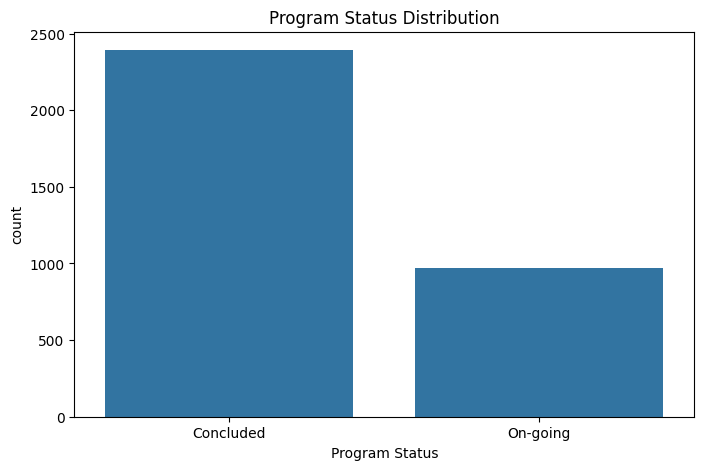

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x="Program Status", data=df2, order=df2["Program Status"].value_counts().index)
plt.title("Program Status Distribution")
plt.show()

### Insights

There are much more concluded programs (2400) than On-going programs (950).

This implies that majority of the students are already graduated and therefore, the dataset is skewed towards alumni or graduates and not the current enrollees.

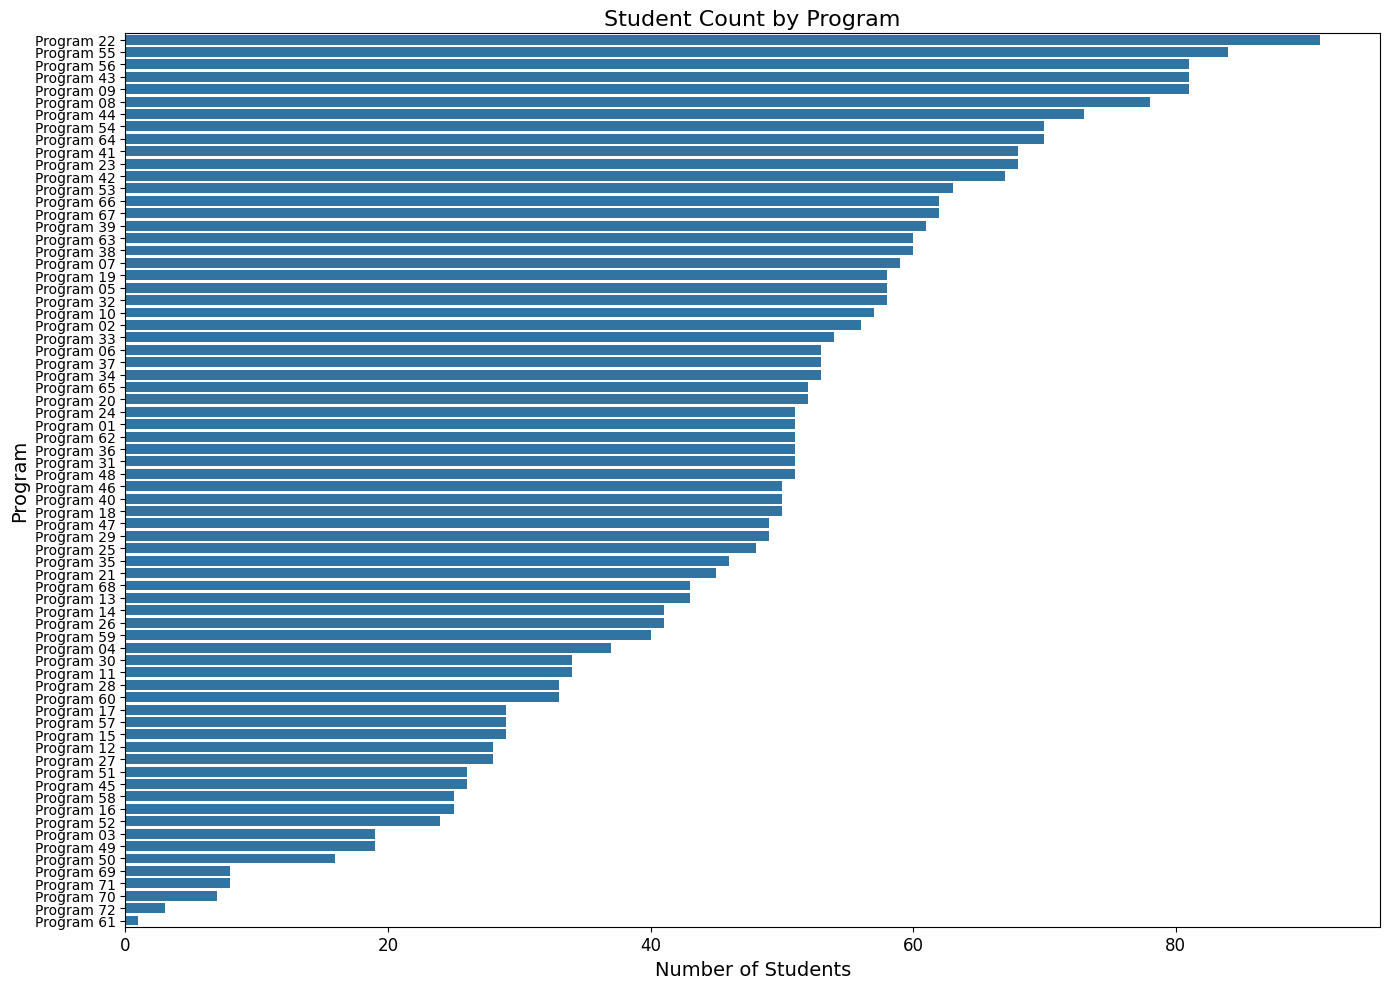

In [37]:
plt.figure(figsize=(14,10))
sns.countplot(
    y="Program",
    data=df2,
    order=df2["Program"].value_counts().index,
)
plt.title("Student Count by Program", fontsize=16)
plt.xlabel("Number of Students", fontsize=14)
plt.ylabel("Program", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Insights

Admission in programs is not balanced.

Some programs (e.g. Program 22, 55, 43) contain the greatest number of students, and there are numerous small-scale programs containing less than 100 students.

The bigger programs can take control over the trends, and the smaller ones can distort averages unless depending on their proper weighting.

## Profile Insights

According to the Profile Insights of the students, most of the students are of the age that is normal age of college within the age of late teens and early twenties, which means that there is a normal age group of college students. The gender balance is quite equal and the majority of students are Philippine nationals as the major proportion in the dataset. Also, the student body includes older clusters of students, probably employed professionals, transfer students, or students with unusual academic backgrounds. The given demographic profiles allow realizing the diverse background of students and can be used to create the specific academic and support programs that would cater to the needs of students.

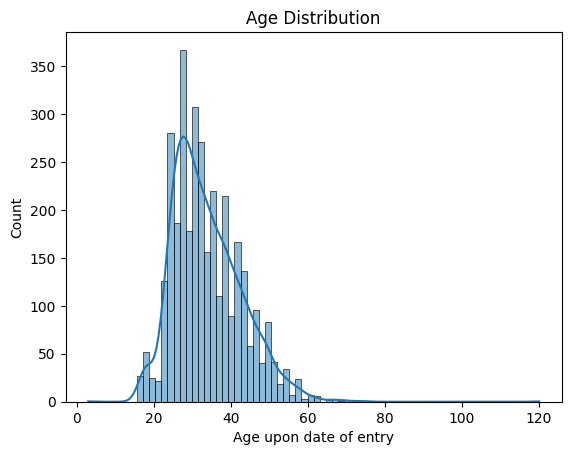

In [38]:
sns.histplot(df2["Age upon date of entry"].dropna(), kde=True)
plt.title("Age Distribution")
plt.show()

### Insights

Most students join college at the anticipated age group (late teenage to early twenties).

Nonetheless, distinct clusters of older students can be observed - maybe working people, transferees, or those who have returned to school after a hiatus.

Correlation analysis reveals that age and final grade are slightly negatively correlated and therefore the older students might have more problems with balance between studies and personal or work-related issues.

In [ ]:
sns.countplot(x="Gender by Birth", data=df2)
plt.title("Gender Distribution")
plt.show()

### Insights

From the chart, male students (2,000) outnumber female students (1,350).

This indicates that the institution has a male-majority enrollment.

In [ ]:
df2["Nationality"] = df2["Nationality"].replace({
    "Filipino": "Philippines",
})

# Plot top 10 nationalities
plt.figure(figsize=(12,8))
top10 = df2["Nationality"].value_counts().head(10).index
sns.countplot(y="Nationality", data=df2,
              order=top10)
plt.title("Top 10 Nationalities of Students")
plt.show()

### Insights

Most of the students are local nationals with a few international students also being represented in the dataset.

These international students are also an indicator of the increasing popularity of the institution outside of the local market, yet they also imply that the institution may need to provide support systems to international students (orientation programs, language assistance, cultural integration).

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="Civil Status", data=df2,
              order=df2["Civil Status"].value_counts().index)
plt.title("Student Count by Civil Status")
plt.show()

### Insights

Most of the students are single although a smaller number are married.

The married students might have time and financial constraints which might limit them to meet the academic requirements at the same rate as the single students.

Civil status has not demonstrated a very strong correlation with the grades but is still a significant demographic variable when studying the possible struggles of students.

In [ ]:
plt.figure(figsize=(10, 6))

# Count and sort
funding_counts = df2["Source of Funding"].value_counts().head(10)

# Simple vertical bar chart
funding_counts.plot(kind="bar", edgecolor="black")

# Titles and labels
plt.title("Top 10 Sources of Student Funding")
plt.xlabel("Source of Funding")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Insights

The top 3 bars (all variants of self-financed, and self-financed + loan/scholarship) are much taller than the rest — they appear to capture the majority of students.

Formal scholarship programs (e.g., ADB-JSP full scholarship) and other smaller categories are in the long tail (relatively few students).

Company sponsorship is visible but far smaller than the self-financed groups.

In [ ]:
plt.figure(figsize=(10, 6))
df2["Student Status"] = df2["Student Status"].str.strip().str.lower()
(df2["Student Status"]
 .value_counts()
 .head(10)
 .sort_values(ascending=False)
 .plot(kind="bar", edgecolor="black"))
plt.title("Student Count by Student Status")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insights

Leave of absence is by far the largest category (~240 from the plot).

Withdrawn is the next largest (~100).

AWOL, failed courses, suspended are very small (single- or low-double digits).

<Figure size 1200x700 with 0 Axes>

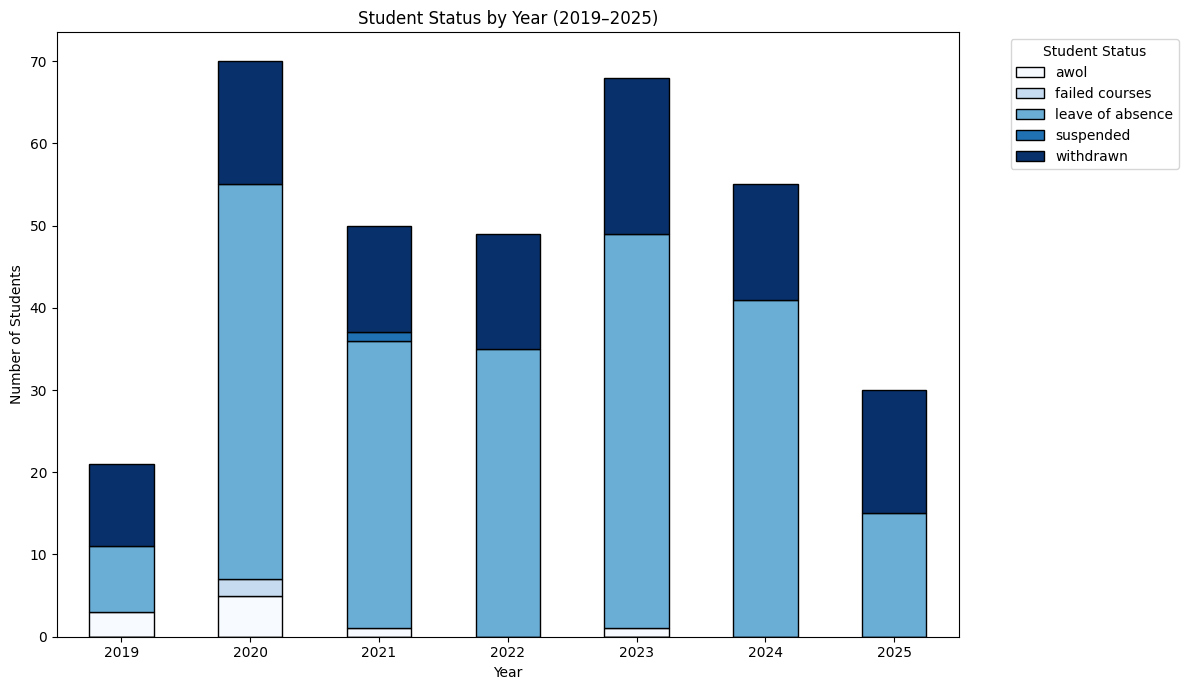

Year with highest count per status (2019–2025):
    Year    Student Status  Count
4   2020              awol      5
5   2020    failed courses      2
6   2020  leave of absence     48
10  2021         suspended      1
16  2023         withdrawn     19


In [39]:
df2 = df2.copy()
df2["Student Status"] = df2["Student Status"].str.strip().str.lower()

date_col = df2["Date of Application for \nLeave of Absence/Withdrawal"].fillna(df2["Date of Last Attended Class"])
df2["Year"] = pd.to_datetime(date_col, errors="coerce").dt.year.astype("Int64")

yearly_status = df2.groupby(["Year", "Student Status"]).size().reset_index(name="Count")

yearly_status = yearly_status[(yearly_status["Year"] >= 2019) & (yearly_status["Year"] <= 2025)]

pivot_table = yearly_status.pivot(index="Year", columns="Student Status", values="Count").fillna(0)

plt.figure(figsize=(12, 7))
pivot_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    edgecolor="black",
    colormap="Blues"
)

plt.title("Student Status by Year (2019–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend(title="Student Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

max_status_per_year = yearly_status.loc[yearly_status.groupby("Student Status")["Count"].idxmax()]
print("Year with highest count per status (2019–2025):")
print(max_status_per_year)

### Insights

Peak Year:
2020 had the highest total number of student statuses recorded.

Most statuses (AWOL, failed courses, leave of absence) also peaked in 2020.

Leave of Absence Dominates:
“Leave of absence” is consistently the largest category each year.

In 2020, there were 48 LOA cases (the highest single-status count across all years).

Withdrawn & Suspended:
“Withdrawn” and “Suspended” appear steadily after 2019, peaking around 2023–2024.

These statuses make up a noticeable portion of the stacked bars.

Anomalous Years:
2002 and 2028 have single-digit counts, which might be data entry errors (outliers compared to 2019–2025).

## Grades Insights

According to the Grade Insights it reveals that the academic performance of the learner is quite good on average with the mean and median final grade of about 4.02 on the grading scale. The grades exhibit moderate consistency, with majority of students having scores ranging between 3.75 (25 th percentile) and 4.25 (75 th percentile), and the median grade is 4.00. The grading scale ranges between 1.00 minimum to 5.00 maximum meaning that there were better-performing students and others were not doing so highly. The distribution indicates that the performance of the student population is generally good with some variation that can probably be attributed to the difference between individuals or life difficulties in programs.

In [ ]:
sns.histplot(df3["Final Grade"].dropna(), kde=True)
plt.title("Grade Distribution")
plt.show()

### Insights

Most grades are between 3.0 and 4.5 with easily noticeable peaks in standard grading points (e.g. 3.0, 3.5, 4.0).

There were very few students who had the grades of 1.0 (excellent) or 5.0 (failing).

This indicates that the majority of students have average to above average performance but there is comparative scarcity of excellence and failure.

The spikes suggest that grading is discrete and standardized (probably whole or half-point grades and not continuous scores).

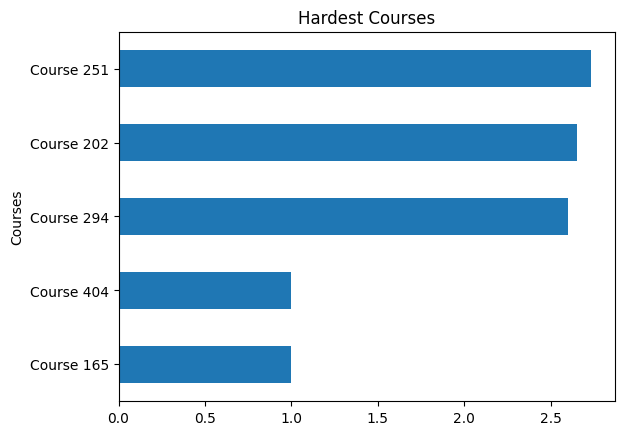

In [40]:
df3.groupby("Courses")["Final Grade"].mean().nsmallest(5).plot(kind="barh", title="Hardest Courses")
plt.show()

### Insights

The most difficult courses are course 251, 202, and 294 that have the lowest average grade (~2.6-2.7).

Course 404 and 165 are taken afterward with a marginally higher average (~1.0).

The low averages in a few courses indicate that they are more work intensive, tougher in content, or more grading intensive.

In [ ]:
plt.figure(figsize=(10, 6))
avg_by_year = (df3
.dropna(subset=["Final Grade"])
.groupby("Academic Year")["Final Grade"]
.mean()
.sort_index())
avg_by_year.plot(kind="line", marker="o")
plt.title("Average Grades per Academic Year")
plt.xlabel("Academic Year")
plt.ylabel("Average Grade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Insights

The average grades started around 3.3 to 3.5 in earlier years.

There is a noticeable drop around the "SY 2017-2018" academic year, where the average grade dips below 3.5, even reaching around 3.4 or lower.

After this dip, average grades steadily rise from about "SY 2018-2019" onward, showing a positive upward trend.

The most recent academic years, "SY 2021-2022" through "SY 2023-2024," have the highest average grades, reaching above 4.4 and close to 4.6.

This upward trend towards recent years indicates improvement in student academic performance over time.

## Correlations

Correlation analysis shows that there is little or no effect on age upon entry on the final grades whereas student status has a strong correlation with performance. Status is one of the best predictors of academic outcomes since disruptions related to enrolment are associated with low grades.

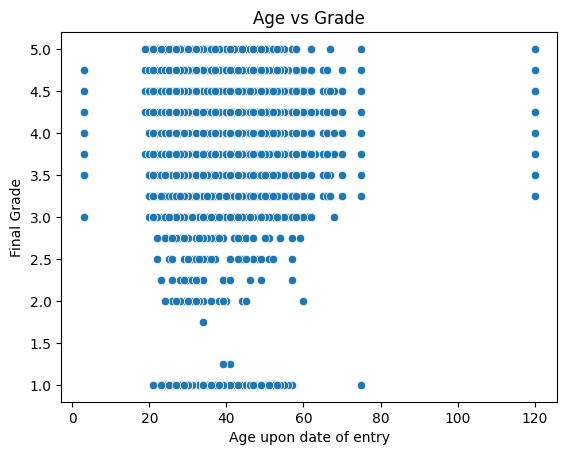

In [41]:
df_merge = df3.merge(df2[["Student","Age upon date of entry"]], on="Student", how="left")
sns.scatterplot(x="Age upon date of entry", y="Final Grade", data=df_merge)
plt.title("Age vs Grade")
plt.show()

### Insights

The values are distributed extensively between grades 1.0 and 5.0 with no evident linear regression.

Students of every age group (teenagers to approximately 60 years and more) are represented throughout the entire range of grades.

The points are not very normal (e.g., there are points close to age 120), which is probably an error of data entry.

Younger Students (18-30 age range)
The majority of the information is concentrated here.

Grades are also distributed widely with most of the students being clumped between 3.0-4.5-average-to-good grades.

None of that indicating the automatic performance of younger students.

Older Students (40-60+)
Secondarily, still scattered over the grade range, but smaller in sample size.

There are those who perform well (4.0-and above), and those who do not (1.0-2.0).

Implicates that age in itself is not a significant predictor of performance - other variables (motivation, life circumstances, support) must be more important.

Outliers (80-120 years old)
Leaves of imagination with regards to the students.

These ought to be considered as a quality of data problem - probably miscoded or default values in the data.

They may not give accurate correlation results when retained, and thus they should not be part of analysis.

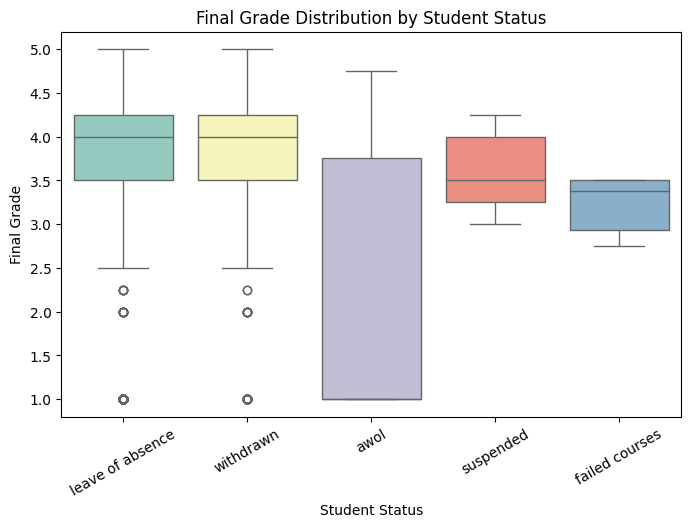

Student Status vs. Final Grade:
                      mean  median  count
Student Status                           
awol              2.226744   1.000     86
failed courses    3.218750   3.375      8
leave of absence  3.731893   4.000   2996
suspended         3.557377   3.500     61
withdrawn         3.767785   4.000    745


In [42]:
# Merge Profile and Grades using "Student"
merged = df2.merge(
    df3[["Student", "Final Grade"]],
    on="Student",
    how="left"
)

# --- Boxplot of grades by student status ---
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Student Status",
    y="Final Grade",
    data=merged,
    hue="Student Status",
    palette="Set3",
    legend=False
)
plt.title("Final Grade Distribution by Student Status")
plt.xticks(rotation=30)
plt.show()

# --- Summary stats ---
student_stats = merged.groupby("Student Status")["Final Grade"].agg(["mean","median","count"])
print("Student Status vs. Final Grade:")
print(student_stats)

### Insights

The values are distributed extensively between grades 1.0 and 5.0 with no evident linear regression.

Students of every age group (teenagers to approximately 60 years and more) are represented throughout the entire range of grades.

The points are not very normal (e.g., there are points close to age 120), which is probably an error of data entry.

Younger Students (18-30 age range)
The majority of the information is concentrated here.

Grades are also distributed widely with most of the students being clumped between 3.0-4.5-average-to-good grades.

None of that indicating the automatic performance of younger students.

Older Students (40-60+)
Secondarily, still scattered over the grade range, but smaller in sample size.

There are those who perform well (4.0-and above), and those who do not (1.0-2.0).

Implicates that age in itself is not a significant predictor of performance - other variables (motivation, life circumstances, support) must be more important.

Outliers (80-120 years old)
Leaves of imagination with regards to the students.

These ought to be considered as a quality of data problem - probably miscoded or default values in the data.

They may not give accurate correlation results when retained, and thus they should not be part of analysis.

## Conclusion

The exploratory data analysis provides a comprehensive overview of student data covering academic performance, program participation, and student demographics. The data indicates that students who are able to complete their academic programs have a high rate of getting final grades as compared to students who are still in the program and have interruptions such as leaves of absence. Statistical profiles of final grades give us the overall average grade of approximately 4.02, varying among students and academic years. According to the time series of grades per academic year, grades were at the lowest point in 2017-2018, and since then, the performance has improved steadily in the recent years. The demographic information consists of a large number of students within college-going age, equal sex representation, and a high number of Philippine students, although a few older students indicate an uneven facility composition.

Trends in academic performance can be monitored to understand when intervention is necessary and confirm that success has been achieved when the institution works towards it. The concept of demographic diversity fosters the development of inclusive and flexible support systems that will ensure the needs of diverse students are met. All in all, data analytics can be used to proactively identify at-risk students, make decisions about them, and implement academic improvements that will lead to increased student achievement and a decreased dropout rate. The trends and insights presented give all the stakeholders in the education sector a strategic platform to keep bettering the learning outcomes and student learning.

## Recommendation

1. Enhancement of Retention Programs:

    * Establish special support services which can help to detect and provide services to those students who are vulnerable to interruptions like leaves of absence or dropouts.
    * Introduce early warning procedures that rely on academic information to identify academically slow students.

2. Enhance Academic Support:

    * Provide tutoring, mentoring and skills training, especially to those students in a program or academic year with lower average grades.
    * Encourage regular visits and participation, and the weeks off seem to be tied to the lack of performance.

3. Personalized Service to a Varied Population:

    * Provide flexible learning and accommodation of the older students and non-traditional students who might have varied challenges and commitments.
    * Take into consideration the cultural and nationality diversity during program development in order to establish inclusive environments.

4. Constantly Check Academic Trends:

    * Analyze data on program and yearly academic performance on a regular basis to identify any emerging problems at an early stage.

Measure intervention effects and optimize interventions with data analytics.

5. Curriculum and Instructional Improvements:

    * Re-examine and revise curricula where academic performance is low to make the content relevant and interesting to students.
    * Develop a faculty that puts emphasis on improving teaching strategies that are student-oriented.

6. Enhance Data Integrity and Quality:

    *  Keep proper and neat academic records to facilitate sound analysis and decision making.
    * Combine multiple data sources of students to gain comprehensive understanding of drivers of performance.

By adopting these recommendations, institutions can be proactive when assisting students, reduce disparities in performances, and ensure successful completion of the programs, which eventually leads to better educational outcomes.